# la Méthode de l'Entropie (EWM).

Le principe est simple : plus une variable (comme le poids) varie de manière importante et imprévisible entre les voitures, plus elle apporte d'information pour différencier la "souffrance". À l'inverse, si toutes les voitures ont le même nombre de documents, ce critère recevra un poids proche de zéro. 
Étape 1 : Normalisation de la matrice de décision Comme vos données ont des unités différentes (kg, \(m^{3}\), minutes), il faut les transformer en valeurs sans unité comprises entre 0 et 1. 




Étape 2 : Calcul de l'entropie de chaque critère L'entropie \(e_{j}\) mesure la dispersion des données pour chaque critère. 
On la calcule ainsi (avec \(n\) le nombre de voitures) :\(e_{j}=-\frac{1}{\ln (n)}\cdot \sum _{i=1}^{n}\gamma _{ij}\ln (\gamma _{ij})\)

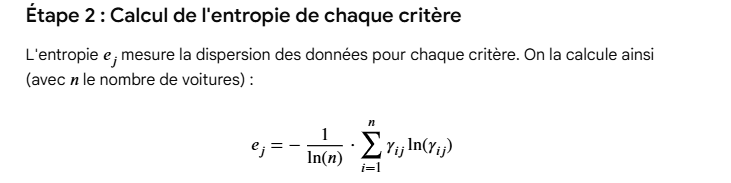

Étape 3 : Calcul des poids objectifs et du score final Le poids \(w_{j}\) de chaque critère est déterminé par son degré de divergence \((1-e_{j})\). 

Plus le critère est diversifié, plus son poids est élevé :\(w_{j}=\frac{1-e_{j}}{\sum (1-e_{j})}\)Le score de difficulté final \(D_{i}\) pour chaque voiture est alors :\(D_{i}=\sum _{j=1}^{m}w_{j}\cdot \gamma _{ij}\)

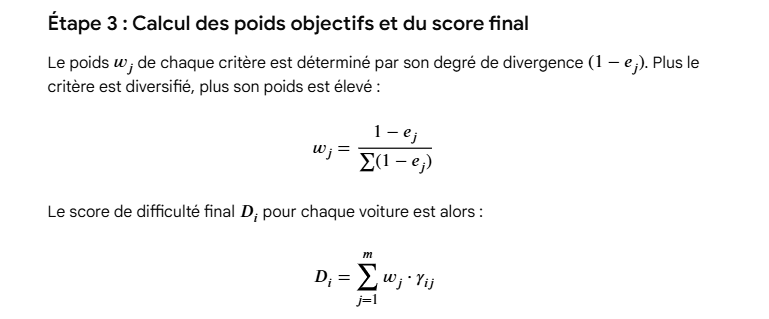

Réponse : La méthode de l'Entropie de Shannon est la solution mathématique idéale. Elle permet de calculer automatiquement l'importance du poids, du volume, des documents et du temps sans aucune intervention humaine. Une voiture sera jugée plus "difficile" si elle présente des valeurs exceptionnellement hautes sur les critères qui varient le plus dans votre échantillon. Pour le critère du temps, veillez à utiliser son inverse (\(1/temps\)) ou le ratio \(Volume/Temps\), car une souffrance élevée est souvent liée à un temps court pour une charge importante (cadence élevée).

In [1]:
import pandas as pd
import numpy as np

# 1. Vos données (exemple)
data = {
    'voiture_id': ['V001', 'V002', 'V003', 'V004'],
    'poids_kg': [1200, 450, 3000, 1500],
    'volume_m3': [15, 5, 25, 12],
    'nb_documents': [5, 2, 12, 6],
    'temps_decharge_min': [60, 20, 150, 45]
}

df = pd.DataFrame(data)

# On garde uniquement les colonnes numériques pour le calcul
cols = ['poids_kg', 'volume_m3', 'nb_documents', 'temps_decharge_min']
matrix = df[cols].values

# 2. Normalisation (Min-Max)
# Pour que toutes les valeurs soient entre 0 et 1
norm_matrix = (matrix - matrix.min(axis=0)) / (matrix.max(axis=0) - matrix.min(axis=0))

# 3. Calcul de la probabilité Pij
# On évite les zéros avec une petite valeur (eps) pour le log
eps = 1e-9
p_matrix = norm_matrix / norm_matrix.sum(axis=0)

# 4. Calcul de l'Entropie (Ej) pour chaque critère
n = len(df)
k = 1.0 / np.log(n)
entropy = -k * np.sum(p_matrix * np.log(p_matrix + eps), axis=0)

# 5. Calcul des Poids (Wj)
# Plus le critère varie, plus son poids est élevé
divergence = 1 - entropy
weights = divergence / divergence.sum()

# 6. Calcul du Score de Difficulté Final
df['score_difficulte'] = np.dot(norm_matrix, weights)

# Affichage des poids calculés automatiquement
print("Poids calculés par l'algorithme :")
for col, w in zip(cols, weights):
    print(f"- {col} : {w:.2%}")

# Classement final (du plus difficile au moins difficile)
df_sorted = df.sort_values(by='score_difficulte', ascending=False)
print("\nClassement des voitures par difficulté de déchargement :")
print(df_sorted[['voiture_id', 'score_difficulte']])


Poids calculés par l'algorithme :
- poids_kg : 24.16%
- volume_m3 : 21.79%
- nb_documents : 24.19%
- temps_decharge_min : 29.86%

Classement des voitures par difficulté de déchargement :
  voiture_id  score_difficulte
2       V003          1.000000
0       V001          0.344458
3       V004          0.329940
1       V002          0.000000
